# OPTIMIZATION

PAPER REPORTED VALUES
zeta     = 0.8222300000 rad
theta    = 1.1426600000 rad
phi      = 2.2642100000 rad
theta_p  = 0.7853900000 rad
phi_p    = 0.7501600000 rad

Tr(F^-1) at rounded paper values:
12.652741531552362
Optimization terminated successfully.
         Current function value: 12.652742
         Iterations: 176
         Function evaluations: 418

OPTIMIZED PARAMETERS
opt_zeta    = 0.822522751844614 rad
opt_theta   = 1.142887565656797 rad
opt_phi     = 2.264371096942413 rad
opt_theta_p = 0.785398162425017 rad
opt_phi_p   = 0.751024158027850 rad

In degrees:
zeta        = 47.127082234182708 deg
theta       = 65.482633970115259 deg
phi         = 129.738907106208842 deg
theta_p     = 44.999999944283765 deg
phi_p       = 43.030514567361976 deg

Tr(F^-1) =
12.652741525828048

Saved optimized parameters to:
optimal_parameters.json

FRAME AT OPTIMUM

F =
[[ 1.00000000e+00  2.41473870e-01 -1.79622549e-02  5.20417043e-18]
 [ 2.41473870e-01  2.43557250e-01  1.90389764e-02  1.16539809e-03

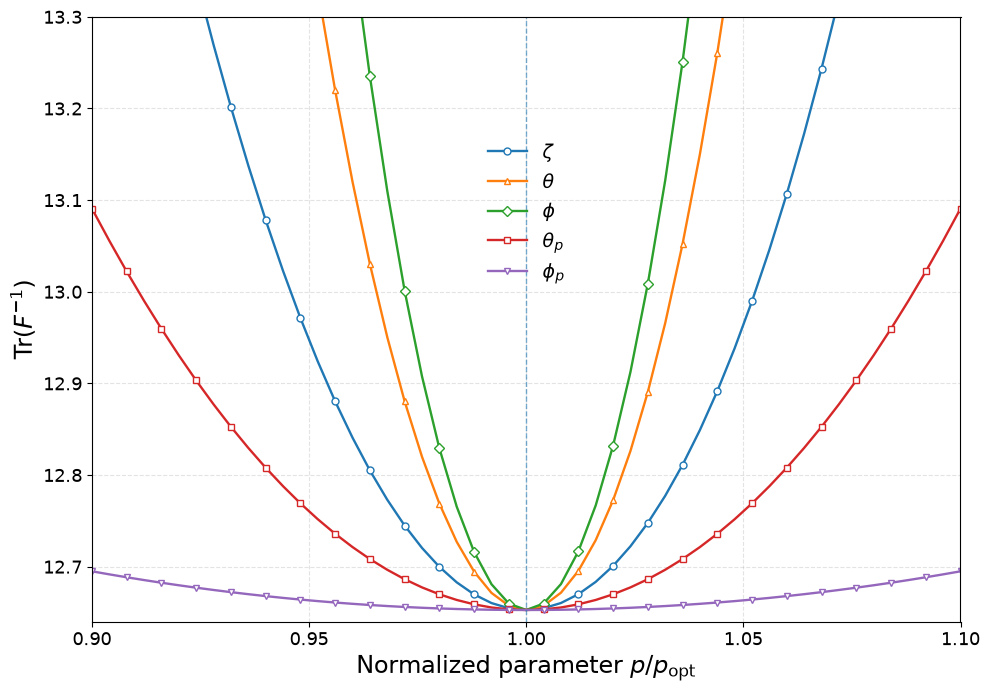

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import json


# ============================================================
# Fixed q-plate parameters
# ============================================================

alpha_1 = 105 * np.pi / 180
alpha_2 = 336 * np.pi / 180


# ============================================================
# Effective measurement operators from Eq. (S14)
# ============================================================

def effective_measurements(zeta, theta, phi, theta_p, phi_p):

    eta = zeta + phi - 2 * theta

    # Projection convention implicit in the displayed S13:
    # |psi> = cos(theta_p)|0> + exp(-i phi_p) sin(theta_p)|1>
    #
    # Therefore the bra contains +i phi_p, giving
    #
    # nu = 4 alpha_1 - 4 alpha_2 - 2 zeta + phi_p + 2 phi

    nu = (
        4 * alpha_1
        - 4 * alpha_2
        - 2 * zeta
        + phi_p
        + 2 * phi
    )

    C_eta = np.cos(eta)
    S_eta = np.sin(eta)

    C_tp = np.cos(theta_p)
    S_tp = np.sin(theta_p)

    S_2eta = np.sin(2 * eta)
    S_2tp = np.sin(2 * theta_p)

    # ------------------------------------------------------------
    # mu_1
    # ------------------------------------------------------------
    mu1 = 0.5 * np.array([
        [0, 0],
        [0, S_eta**2 * C_tp**2]
    ], dtype=complex)

    # ------------------------------------------------------------
    # mu_2
    # ------------------------------------------------------------
    mu2 = 0.5 * np.array([
        [S_eta**2 * S_tp**2, 0],
        [0, 0]
    ], dtype=complex)

    # ------------------------------------------------------------
    # mu_3
    # Corrected from V-tilde:
    # upper-right  ~ exp(+2 i zeta)
    # lower-left   ~ exp(-2 i zeta)
    # ------------------------------------------------------------
    mu3 = 0.5 * np.array([
        [
            S_eta**2 * C_tp**2,
            -0.5 * np.exp(+2j * zeta)
            * S_2eta * C_tp**2
        ],
        [
            -0.5 * np.exp(-2j * zeta)
            * S_2eta * C_tp**2,
            C_eta**2 * C_tp**2
        ]
    ], dtype=complex)

    # ------------------------------------------------------------
    # mu_4
    # Corrected from V-tilde:
    # upper-right  ~ exp(+i nu)
    # lower-left   ~ exp(-i nu)
    # ------------------------------------------------------------
    mu4 = 0.5 * np.array([
        [
            C_eta**2 * C_tp**2,
            0.5 * np.exp(+1j * nu)
            * C_eta**2 * S_2tp
        ],
        [
            0.5 * np.exp(-1j * nu)
            * C_eta**2 * S_2tp,
            C_eta**2 * S_tp**2
        ]
    ], dtype=complex)

    # ------------------------------------------------------------
    # mu_5
    # Corrected from V-tilde:
    # upper-right  ~ exp(+2 i zeta)
    # lower-left   ~ exp(-2 i zeta)
    # ------------------------------------------------------------
    mu5 = 0.5 * np.array([
        [
            C_eta**2 * S_tp**2,
            0.5 * np.exp(+2j * zeta)
            * S_2eta * S_tp**2
        ],
        [
            0.5 * np.exp(-2j * zeta)
            * S_2eta * S_tp**2,
            S_eta**2 * S_tp**2
        ]
    ], dtype=complex)

    return [mu1, mu2, mu3, mu4, mu5]


# ============================================================
# Pauli basis
# ============================================================

I = np.eye(2, dtype=complex)

sigma_x = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

sigma_y = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sigma_z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

basis = [
    I / np.sqrt(2),
    sigma_x / np.sqrt(2),
    sigma_y / np.sqrt(2),
    sigma_z / np.sqrt(2)
]


# ============================================================
# Frame superoperator F
#
# Eq. (S9), with d = 2
# ============================================================

def frame_matrix(params):

    zeta, theta, phi, theta_p, phi_p = params

    mus = effective_measurements(
        zeta,
        theta,
        phi,
        theta_p,
        phi_p
    )

    F = np.zeros((4, 4), dtype=float)

    for i, B_i in enumerate(basis):

        for j, B_j in enumerate(basis):

            for mu in mus:

                tr_mu = np.trace(mu).real

                if tr_mu < 1e-14:
                    continue

                F[i, j] += (
                    np.trace(B_i @ mu)
                    * np.trace(mu @ B_j)
                    / (tr_mu / 2)
                ).real

    # Remove tiny numerical asymmetries
    F = 0.5 * (F + F.T)

    return F


# ============================================================
# Objective
# ============================================================

def objective(params):

    F = frame_matrix(params)

    eigvals = np.linalg.eigvalsh(F)

    if eigvals.min() <= 1e-12:
        return 1e12

    try:
        return np.trace(np.linalg.inv(F))
    except np.linalg.LinAlgError:
        return 1e12


# ============================================================
# Paper's reported values, Eq. (S16)
#
# Used as the starting point for local optimization
# ============================================================

paper_values = np.array([
    0.82223,
    1.14266,
    2.26421,
    0.78539,
    0.75016
])


# ============================================================
# Print paper values
# ============================================================

print("=" * 70)
print("PAPER REPORTED VALUES")
print("=" * 70)

names = [
    "zeta",
    "theta",
    "phi",
    "theta_p",
    "phi_p"
]

for name, value in zip(names, paper_values):
    print(f"{name:8s} = {value:.10f} rad")

print("\nTr(F^-1) at rounded paper values:")
print(objective(paper_values))


# ============================================================
# LOCAL OPTIMIZATION STARTING FROM PAPER VALUES
# ============================================================

result = minimize(
    objective,
    paper_values,
    method="Nelder-Mead",
    options={
        "maxiter": 50000,
        "xatol": 1e-12,
        "fatol": 1e-14,
        "disp": True
    }
)


# ============================================================
# OPTIMIZED PARAMETERS
# ============================================================

p_opt = result.x.copy()


# ============================================================
# Store individually
# ============================================================

opt_zeta = p_opt[0]
opt_theta = p_opt[1]
opt_phi = p_opt[2]
opt_theta_p = p_opt[3]
opt_phi_p = p_opt[4]


# ============================================================
# Print optimized values
# ============================================================

print("\n" + "=" * 70)
print("OPTIMIZED PARAMETERS")
print("=" * 70)

print(f"opt_zeta    = {opt_zeta:.15f} rad")
print(f"opt_theta   = {opt_theta:.15f} rad")
print(f"opt_phi     = {opt_phi:.15f} rad")
print(f"opt_theta_p = {opt_theta_p:.15f} rad")
print(f"opt_phi_p   = {opt_phi_p:.15f} rad")

print("\nIn degrees:")

print(f"zeta        = {np.degrees(opt_zeta):.15f} deg")
print(f"theta       = {np.degrees(opt_theta):.15f} deg")
print(f"phi         = {np.degrees(opt_phi):.15f} deg")
print(f"theta_p     = {np.degrees(opt_theta_p):.15f} deg")
print(f"phi_p       = {np.degrees(opt_phi_p):.15f} deg")

print("\nTr(F^-1) =")
print(f"{objective(p_opt):.15f}")


# ============================================================
# SAVE OPTIMIZED PARAMETERS TO JSON
# ============================================================

optimal_parameters = {
    "opt_zeta": float(opt_zeta),
    "opt_theta": float(opt_theta),
    "opt_phi": float(opt_phi),
    "opt_theta_p": float(opt_theta_p),
    "opt_phi_p": float(opt_phi_p)
}

with open("optimal_parameters_corrected.json", "w") as f:
    json.dump(
        optimal_parameters,
        f,
        indent=4
    )

print("\nSaved optimized parameters to:")
print("optimal_parameters.json")


# ============================================================
# Frame at optimum
# ============================================================

F_opt = frame_matrix(p_opt)

eigvals = np.linalg.eigvalsh(F_opt)

print("\n" + "=" * 70)
print("FRAME AT OPTIMUM")
print("=" * 70)

print("\nF =")
print(F_opt)

print("\nEigenvalues =")
print(eigvals)

print("\nTr(F^-1) =")
print(np.trace(np.linalg.inv(F_opt)))


# ============================================================
# FIGURE S1
#
# Each parameter is perturbed independently.
# All other parameters remain at the optimum.
#
# x-axis = p / p_opt
# ============================================================

x = np.linspace(0.90, 1.10, 51)

param_labels = [
    r'$\zeta$',
    r'$\theta$',
    r'$\phi$',
    r'$\theta_p$',
    r'$\phi_p$'
]

markers = [
    'o',
    '^',
    'D',
    's',
    'v'
]


# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 7)
)


for p_idx in range(5):

    values = []

    for scale in x:

        # Copy optimized parameters
        params = p_opt.copy()

        # Perturb only one parameter
        params[p_idx] = p_opt[p_idx] * scale

        # Calculate objective
        values.append(
            objective(params)
        )

    values = np.asarray(values)

    ax.plot(
        x,
        values,
        linewidth=1.7,
        marker=markers[p_idx],
        markersize=5,
        markerfacecolor='white',
        markeredgewidth=1.0,
        markevery=2,
        label=param_labels[p_idx]
    )


# ============================================================
# Reference line
# ============================================================

ax.axvline(
    1.0,
    linestyle='--',
    linewidth=1.0,
    alpha=0.6
)


# ============================================================
# Axis settings
# ============================================================

ax.set_xlim(0.90, 1.10)

ax.set_ylim(12.64, 13.30)

ax.set_xticks([
    0.90,
    0.95,
    1.00,
    1.05,
    1.10
])

ax.set_yticks([
    12.7,
    12.8,
    12.9,
    13.0,
    13.1,
    13.2,
    13.3
])


# ============================================================
# Labels
# ============================================================

ax.set_xlabel(
    r'Normalized parameter $p/p_{\mathrm{opt}}$',
    fontsize=17
)

ax.set_ylabel(
    r'$\mathrm{Tr}(F^{-1})$',
    fontsize=17
)


# ============================================================
# Grid
# ============================================================

ax.grid(
    True,
    linestyle='--',
    alpha=0.35
)


# ============================================================
# Legend
# ============================================================

ax.legend(
    fontsize=14,
    frameon=False,
    loc='upper center',
    bbox_to_anchor=(0.50, 0.82)
)


# ============================================================
# Tick size
# ============================================================

ax.tick_params(
    axis='both',
    labelsize=13
)


# ============================================================
# Layout
# ============================================================

plt.tight_layout()

plt.show()

# HELPER FUNCTIONS - 1

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
import json

with open("optimal_parameters_corrected.json", "r") as f:
    opt = json.load(f)

# Angle conversion
deg = np.pi / 180
TOL = 1e-12

# Polarization basis
H = np.array([1, 0], dtype=complex)
V = np.array([0, 1], dtype=complex)

def dagger(A):
    """Hermitian conjugate A†."""
    return np.conjugate(A.T)

def normalize(psi):
    """Normalize a Jones vector."""
    norm = np.linalg.norm(psi)

    if norm == 0:
        raise ValueError("Zero state cannot be normalized.")

    return psi / norm

def bloch_vector(psi):
    """
    Return the Bloch/Stokes vector (Sx, Sy, Sz)
    for a normalized polarization state |psi>.
    """

    psi = normalize(psi)

    a = psi[0]
    b = psi[1]

    Sx = 2 * np.real(np.conjugate(a) * b)
    Sy = 2 * np.imag(np.conjugate(a) * b)
    Sz = np.abs(a)**2 - np.abs(b)**2

    return np.array([Sx, Sy, Sz])

# INPUT STATE PREPARATION

In [27]:
def rotation(theta):
    """
    Polarization rotation matrix.

    theta: angle in radians
    """
    c = np.cos(theta)
    s = np.sin(theta)

    return np.array([
        [c, -s],
        [s,  c]
    ], dtype=complex)

def waveplate(theta, retardance):
    phase = np.array([
        [np.exp(-1j * retardance / 2), 0],
        [0, np.exp(+1j * retardance / 2)]
    ], dtype=complex)

    return rotation(theta) @ phase @ rotation(-theta)

def HWP(theta):
    """Half-wave plate."""
    return waveplate(theta, np.pi)


def QWP(theta):
    """Quarter-wave plate."""
    return waveplate(theta, np.pi / 2)

def PBS(output="H"):
    """
    Ideal PBS for the input state-preparation stage.

    output = "H" or "V"

    Returns the polarization state selected by the PBS.
    """
    output = output.upper()

    if output == "H":
        return H.copy()

    if output == "V":
        return V.copy()

    raise ValueError("PBS output must be 'H' or 'V'.")

def prepare_input_state(pbs_output, hwp_angle, qwp_angle):
    """
    PBS → HWP → QWP

    Angles are given in radians internally.
    """

    psi = PBS(pbs_output)

    psi = HWP(hwp_angle) @ psi
    psi = QWP(qwp_angle) @ psi

    return psi

# HELPER FUNCTIONS - 2

In [28]:
B_LR_from_HV = np.array([
    [1,  1j],
    [1, -1j]
], dtype=complex) / np.sqrt(2)

def HV_to_LR(psi):
    return B_LR_from_HV @ psi

def LR_to_HV(psi):
    return dagger(B_LR_from_HV) @ psi

def add_oam(psi_LR, n=0):
    """
    Append OAM mode |n> to a polarization state
    expressed in the L/R basis.

    Input:
        psi_LR = [L amplitude, R amplitude]

    Output:
        dictionary representing the joint state
    """

    state = {}

    if abs(psi_LR[0]) > 1e-12:
        state[("L", n)] = psi_LR[0]

    if abs(psi_LR[1]) > 1e-12:
        state[("R", n)] = psi_LR[1]

    return state

# Q-Plate

In [29]:
def qplate(state, alpha, delta):
    """
    Apply the q-plate transformation S(alpha, delta)
    to a dynamically represented polarization-OAM state.

    alpha : q-plate characteristic angle [radians]
    delta : retardance [radians]
    """

    new_state = {}

    c = np.cos(delta / 2)
    s = 1j * np.sin(delta / 2)

    for (pol, n), amplitude in state.items():

        if pol == "L":

            # Stationary component:
            new_state[("L", n)] = (
                new_state.get(("L", n), 0)
                + c * amplitude
            )

            # Shifted component:
            new_state[("R", n + 1)] = (
                new_state.get(("R", n + 1), 0)
                + s * np.exp(-2j * alpha) * amplitude
            )

        elif pol == "R":

            # Stationary component:
            new_state[("R", n)] = (
                new_state.get(("R", n), 0)
                + c * amplitude
            )

            # Shifted component:
            new_state[("L", n - 1)] = (
                new_state.get(("L", n - 1), 0)
                + s * np.exp(2j * alpha) * amplitude
            )

    # Remove numerical zeros
    new_state = {
        key: amplitude
        for key, amplitude in new_state.items()
        if abs(amplitude) > 1e-12
    }

    return new_state

# COIN OPERATION

In [30]:
def coin_matrix(zeta, theta, phi):
    return (
        B_LR_from_HV
        @ QWP(phi)
        @ HWP(theta)
        @ QWP(zeta)
        @ dagger(B_LR_from_HV)
    )

def apply_coin(state, zeta, theta, phi):
    """
    Apply the polarization-only coin operation
    to every occupied OAM mode.

    OAM n is unchanged.
    """

    C = coin_matrix(zeta, theta, phi)

    new_state = {}

    # Find all OAM modes currently present
    oam_modes = {
        n for (pol, n) in state.keys()
    }

    for n in oam_modes:

        # Current L/R amplitudes
        c_L = state.get(("L", n), 0.0)
        c_R = state.get(("R", n), 0.0)

        polarization = np.array([
            c_L,
            c_R
        ], dtype=complex)

        # Apply coin
        transformed = C @ polarization

        # Store resulting amplitudes
        if abs(transformed[0]) > TOL:
            new_state[("L", n)] = transformed[0]

        if abs(transformed[1]) > TOL:
            new_state[("R", n)] = transformed[1]

    return new_state

# PROJECTIONS

In [31]:
# --------------------------------------------------
# POLARIZATION PROJECTION
# --------------------------------------------------

def polarization_projection(state, psi_proj):
    """
    Project the polarization of the state onto psi_proj
    and return the remaining OAM state.

    psi_proj must be a normalized polarization ket in the L/R basis.
    """

    oam_state = {}

    oam_modes = {n for (pol, n) in state.keys()}

    for n in oam_modes:

        c_L = state.get(("L", n), 0.0)
        c_R = state.get(("R", n), 0.0)

        polarization = np.array(
            [c_L, c_R],
            dtype=complex
        )

        amplitude = np.vdot(psi_proj, polarization)

        if abs(amplitude) > TOL:
            oam_state[n] = amplitude

    return oam_state

def analyzer_projection_state(hwp_angle, qwp_angle, pbs_output="H"):
    """
    Return the polarization state projected by

        HWP -> QWP -> PBS

    expressed in the L/R basis.
    """

    pbs_output = pbs_output.upper()

    if pbs_output not in ("H", "V"):
        raise ValueError("pbs_output must be 'H' or 'V'.")

    U = QWP(qwp_angle) @ HWP(hwp_angle)

    selected = H if pbs_output == "H" else V

    # Back-propagate the selected PBS state
    psi_HV = dagger(U) @ selected

    # Convert to L/R
    psi_LR = HV_to_LR(psi_HV)

    return normalize(psi_LR)


def SLM_probability(oam_state, target_mode):
    """
    Probability of detecting the selected OAM mode.
    """
    amplitude = oam_state.get(target_mode, 0.0)

    return abs(amplitude)**2


def find_analyzer_angles(theta_p, phi_p, pbs_output="H"):

    # theta_p, phi_p define the projection state in H/V
    target_HV = np.array([
        np.cos(theta_p),
        np.exp(-1j * phi_p) * np.sin(theta_p)
    ], dtype=complex)

    target_HV = normalize(target_HV)

    # Convert the desired projection state H/V -> L/R
    target_LR = HV_to_LR(target_HV)

    def cost(x):

        hwp_angle, qwp_angle = x

        generated = analyzer_projection_state(
            hwp_angle,
            qwp_angle,
            pbs_output
        )

        overlap = np.abs(
            np.vdot(generated, target_LR)
        ) ** 2

        return 1.0 - overlap

    result = differential_evolution(
        cost,
        [
            (0, np.pi),
            (0, np.pi)
        ],
        seed=42,
        tol=1e-12,
        polish=True
    )

    hwp_opt, qwp_opt = result.x

    return hwp_opt, qwp_opt

# Setup

In [32]:
# ------------------------------------------------------------
# Fixed experimental parameters
# ------------------------------------------------------------

alpha_1 = 105 * deg
delta_1 = np.pi / 2

alpha_2 = 336 * deg
delta_2 = np.pi

hwp_out = 0 * deg
qwp_out = 0 * deg
pbs_out = "H"


# ------------------------------------------------------------
# Random but fixed reservoir coin
# ------------------------------------------------------------

coin_rng = np.random.default_rng()

zeta_c = coin_rng.uniform(0, np.pi)
theta_c = coin_rng.uniform(0, np.pi)
phi_c = coin_rng.uniform(0, np.pi)

print("Fixed random coin:")
print(f"ζ = {zeta_c / deg:.3f}°")
print(f"θ = {theta_c / deg:.3f}°")
print(f"φ = {phi_c / deg:.3f}°")

# --------------------------------------------------
# OPTIMAL PARAMETERS
# --------------------------------------------------

opt_zeta = opt["opt_zeta"]
opt_theta = opt["opt_theta"]
opt_phi = opt["opt_phi"]
opt_theta_p = opt["opt_theta_p"]
opt_phi_p = opt["opt_phi_p"]

# --------------------------------------------------
# RANDOM OUTPUT PROJECTION
# --------------------------------------------------

hwp_out = np.random.uniform(0, 2*np.pi)
qwp_out = np.random.uniform(0, 2*np.pi)
pbs_out = np.random.choice(["H", "V"])

random_projection = analyzer_projection_state(
    hwp_out,
    qwp_out,
    pbs_out
)

print("Random output analyzer:")
print(f"HWP = {hwp_out / deg:.3f}°")
print(f"QWP = {qwp_out / deg:.3f}°")
print(f"PBS = {pbs_out}")

# --------------------------------------------------
# OPTIMAL OUTPUT PROJECTION
# --------------------------------------------------

hwp_opt_out, qwp_opt_out = \
    find_analyzer_angles(
        opt_theta_p,
        opt_phi_p,
        "H"
    )

opt_projection = analyzer_projection_state(
    hwp_opt_out,
    qwp_opt_out,
    "H"
)

# ------------------------------------------------------------
# Optical propagation
# ------------------------------------------------------------

def propagate_input(psi_HV):

    # Convert to L/R
    psi_LR = HV_to_LR(psi_HV)

    # Initial OAM
    state = add_oam(psi_LR, 0)

    # Reservoir
    state = qplate(state, alpha_1, delta_1)

    state = apply_coin(
        state,
        zeta_c,
        theta_c,
        phi_c
    )

    state = qplate(state, alpha_2, delta_2)

    # Random output polarization projection
    oam_state = polarization_projection(
        state,
        random_projection
    )

    return oam_state

# --------------------------------------------------
# OPTIMAL QELM PROPAGATION
# --------------------------------------------------

def propagate_input_opt(psi_HV):

    # Convert input polarization H/V -> L/R
    psi_LR = HV_to_LR(psi_HV)

    # Add OAM n=0
    state = add_oam(psi_LR, n=0)

    # First Q-plate
    state = qplate(
        state,
        alpha_1,
        delta_1
    )

    # Optimal coin
    state = apply_coin(
        state,
        opt_zeta,
        opt_theta,
        opt_phi
    )

    # Second Q-plate
    state = qplate(
        state,
        alpha_2,
        delta_2
    )

    # Optimal polarization projection   
    oam_state = polarization_projection(
        state,
        opt_projection
    )

    return oam_state

Fixed random coin:
ζ = 39.519°
θ = 19.889°
φ = 12.849°
Random output analyzer:
HWP = 326.300°
QWP = 256.739°
PBS = H


# ELM

In [33]:
# --------------------------------------------------
# GENERATE THE SAME INPUT STATES FOR BOTH
# --------------------------------------------------

n_samples = 300
n_train_total = n_samples // 2
n_test = n_samples - n_train_total
rng = np.random.default_rng()

input_settings = []

for _ in range(n_samples):

    pbs_output = rng.choice(["H", "V"])
    hwp_angle = rng.uniform(0, 2*np.pi)
    qwp_angle = rng.uniform(0, 2*np.pi)

    input_settings.append(
        (pbs_output, hwp_angle, qwp_angle)
    )

# --------------------------------------------------
# BUILD INPUT KETS
# --------------------------------------------------

input_states = []

for pbs_output, hwp_angle, qwp_angle in input_settings:

    psi = prepare_input_state(
        pbs_output,
        hwp_angle,
        qwp_angle
    )

    input_states.append(psi)

raw_samples_random = []

for psi in input_states:
    raw_samples_random.append(
        propagate_input(psi)
    )


raw_samples_opt = []

for psi in input_states:
    raw_samples_opt.append(
        propagate_input_opt(psi)
    )

Y_all = np.array([
    bloch_vector(psi)
    for psi in input_states
])

Y_train = Y_all[:n_train_total]
Y_test = Y_all[n_train_total:]

# ------------------------------------------------------------
# Determine the fixed feature ordering ONCE
# ------------------------------------------------------------

feature_modes = sorted(
    {
        n
        for dataset in [raw_samples_random, raw_samples_opt]
        for oam_state in dataset
        for n in oam_state.keys()
    }
)

print("Feature modes:", feature_modes)

def noisy_features_from_oam(oam_state, photons, rng):
    p = np.array([
        SLM_probability(oam_state, n)
        for n in feature_modes
    ])

    total = np.sum(p)

    if total < TOL:
        return np.zeros(len(feature_modes))

    # Probability distribution conditioned on a detected photon
    p_cond = p / total

    # Number of detected photons should depend on total projection probability
    detected = rng.binomial(photons, total)

    if detected == 0:
        return np.zeros(len(feature_modes))

    counts = rng.multinomial(detected, p_cond)

    # IMPORTANT:
    # normalize by the original incident photon number,
    # not by detected photons
    return counts / photons

# --------------------------------------------------
# MAKE NOISY FEATURES
# --------------------------------------------------

def make_noisy_features(raw_samples, photons, rng):

    X = []

    for oam_state in raw_samples:

        features = noisy_features_from_oam(
            oam_state,
            photons,
            rng
        )

        X.append(features)

    return np.array(X)

# --------------------------------------------------
# TRAIN QELM
# --------------------------------------------------

def train_qelm(X_train, Y_train):

    W = np.linalg.pinv(X_train) @ Y_train

    return W

def predict_qelm(X, W):

    return X @ W

# --------------------------------------------------
# FIXED TRAIN / TEST SPLIT
# --------------------------------------------------

Y_all = np.array([
    bloch_vector(psi)
    for psi in input_states
])

Y_train = Y_all[:n_train_total]
Y_test = Y_all[n_train_total:]

Feature modes: [-2, -1, 0, 1, 2]


# MSE vs Photon count

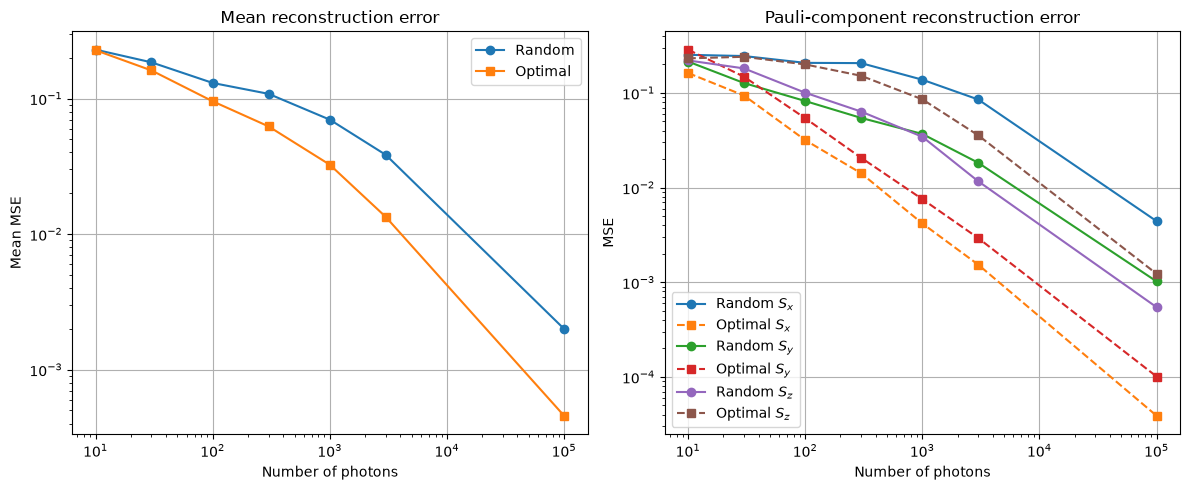

In [34]:
# --------------------------------------------------
# PHOTON NUMBER STUDY
# --------------------------------------------------

photon_numbers = [10, 30, 100, 300, 1000, 3000, 100000]

mse_random_photons = []
mse_opt_photons = []

component_random_photons = []
component_opt_photons = []

for photons in photon_numbers:

    rng_random = np.random.default_rng()
    rng_opt = np.random.default_rng()

    # Random QELM
    X_random = make_noisy_features(
        raw_samples_random,
        photons,
        rng_random
    )

    W_random = train_qelm(
        X_random[:n_train_total],
        Y_train
    )

    Y_pred_random = predict_qelm(
        X_random[n_train_total:],
        W_random
    )

    errors_random = (Y_pred_random - Y_test)**2

    mse_random_photons.append(
        np.mean(errors_random)
    )

    component_random_photons.append(
        np.mean(errors_random, axis=0)
    )


    # Optimal QELM
    X_opt = make_noisy_features(
        raw_samples_opt,
        photons,
        rng_opt
    )

    W_opt = train_qelm(
        X_opt[:n_train_total],
        Y_train
    )

    Y_pred_opt = predict_qelm(
        X_opt[n_train_total:],
        W_opt
    )

    errors_opt = (Y_pred_opt - Y_test)**2

    mse_opt_photons.append(
        np.mean(errors_opt)
    )

    component_opt_photons.append(
        np.mean(errors_opt, axis=0)
    )


component_random_photons = np.array(component_random_photons)
component_opt_photons = np.array(component_opt_photons)

# --------------------------------------------------
# PHOTON NUMBER PLOT
# --------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Mean MSE
ax[0].loglog(
    photon_numbers,
    mse_random_photons,
    'o-',
    label='Random'
)

ax[0].loglog(
    photon_numbers,
    mse_opt_photons,
    's-',
    label='Optimal'
)

ax[0].set_xlabel("Number of photons")
ax[0].set_ylabel("Mean MSE")
ax[0].set_title("Mean reconstruction error")
ax[0].legend()
ax[0].grid(True)


# Individual components
labels = [r"$S_x$", r"$S_y$", r"$S_z$"]

for i, label in enumerate(labels):

    ax[1].loglog(
        photon_numbers,
        component_random_photons[:, i],
        'o-',
        label=f"Random {label}"
    )

    ax[1].loglog(
        photon_numbers,
        component_opt_photons[:, i],
        's--',
        label=f"Optimal {label}"
    )

ax[1].set_xlabel("Number of photons")
ax[1].set_ylabel("MSE")
ax[1].set_title("Pauli-component reconstruction error")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# MSE vs Training Data 

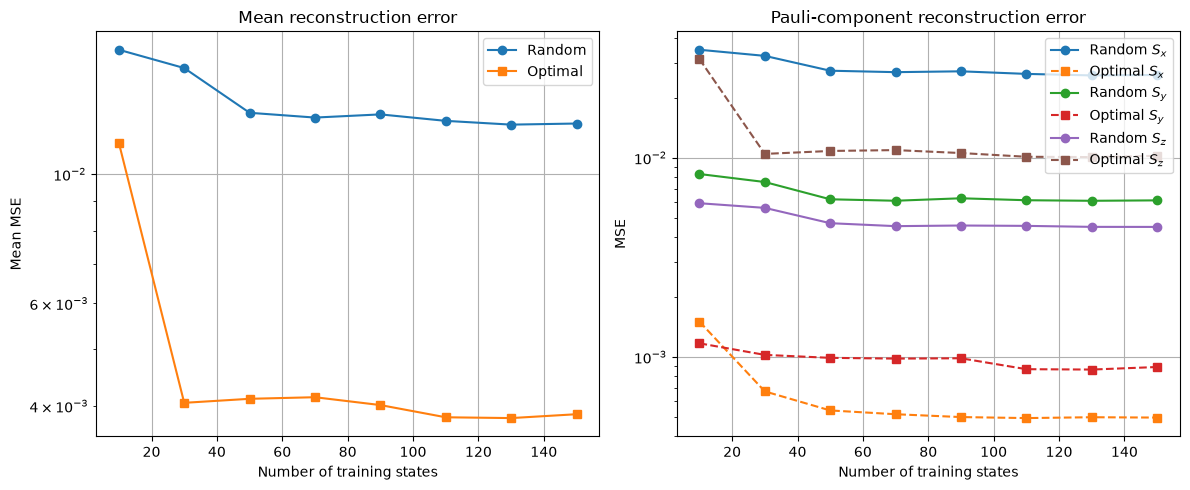

In [35]:
# --------------------------------------------------
# FIXED PHOTON NUMBER FOR TRAINING-SIZE STUDY
# --------------------------------------------------

photons_fixed = 10000

rng_random = np.random.default_rng()
rng_opt = np.random.default_rng()

X_random_fixed = make_noisy_features(
    raw_samples_random,
    photons_fixed,
    rng_random
)

X_opt_fixed = make_noisy_features(
    raw_samples_opt,
    photons_fixed,
    rng_opt
)

# --------------------------------------------------
# TRAINING SIZE STUDY
# --------------------------------------------------

train_sizes = np.unique(
    np.linspace(
        10,
        n_train_total,
        8,
        dtype=int
    )
)

mse_random_train = []
mse_opt_train = []

component_random_train = []
component_opt_train = []

for n_train in train_sizes:

    # Random
    W_random = train_qelm(
        X_random_fixed[:n_train],
        Y_train[:n_train]
    )

    Y_pred_random = predict_qelm(
        X_random_fixed[n_train_total:],
        W_random
    )

    errors_random = (
        Y_pred_random - Y_test
    )**2

    mse_random_train.append(
        np.mean(errors_random)
    )

    component_random_train.append(
        np.mean(errors_random, axis=0)
    )


    # Optimal
    W_opt = train_qelm(
        X_opt_fixed[:n_train],
        Y_train[:n_train]
    )

    Y_pred_opt = predict_qelm(
        X_opt_fixed[n_train_total:],
        W_opt
    )

    errors_opt = (
        Y_pred_opt - Y_test
    )**2

    mse_opt_train.append(
        np.mean(errors_opt)
    )

    component_opt_train.append(
        np.mean(errors_opt, axis=0)
    )


component_random_train = np.array(component_random_train)
component_opt_train = np.array(component_opt_train)

# --------------------------------------------------
# TRAINING SIZE PLOT
# --------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Mean MSE
ax[0].semilogy(
    train_sizes,
    mse_random_train,
    'o-',
    label='Random'
)

ax[0].semilogy(
    train_sizes,
    mse_opt_train,
    's-',
    label='Optimal'
)

ax[0].set_xlabel("Number of training states")
ax[0].set_ylabel("Mean MSE")
ax[0].set_title("Mean reconstruction error")
ax[0].legend()
ax[0].grid(True)


# Individual components
labels = [r"$S_x$", r"$S_y$", r"$S_z$"]

for i, label in enumerate(labels):

    ax[1].semilogy(
        train_sizes,
        component_random_train[:, i],
        'o-',
        label=f"Random {label}"
    )

    ax[1].semilogy(
        train_sizes,
        component_opt_train[:, i],
        's--',
        label=f"Optimal {label}"
    )

ax[1].set_xlabel("Number of training states")
ax[1].set_ylabel("MSE")
ax[1].set_title("Pauli-component reconstruction error")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Bloch State Reconstruction

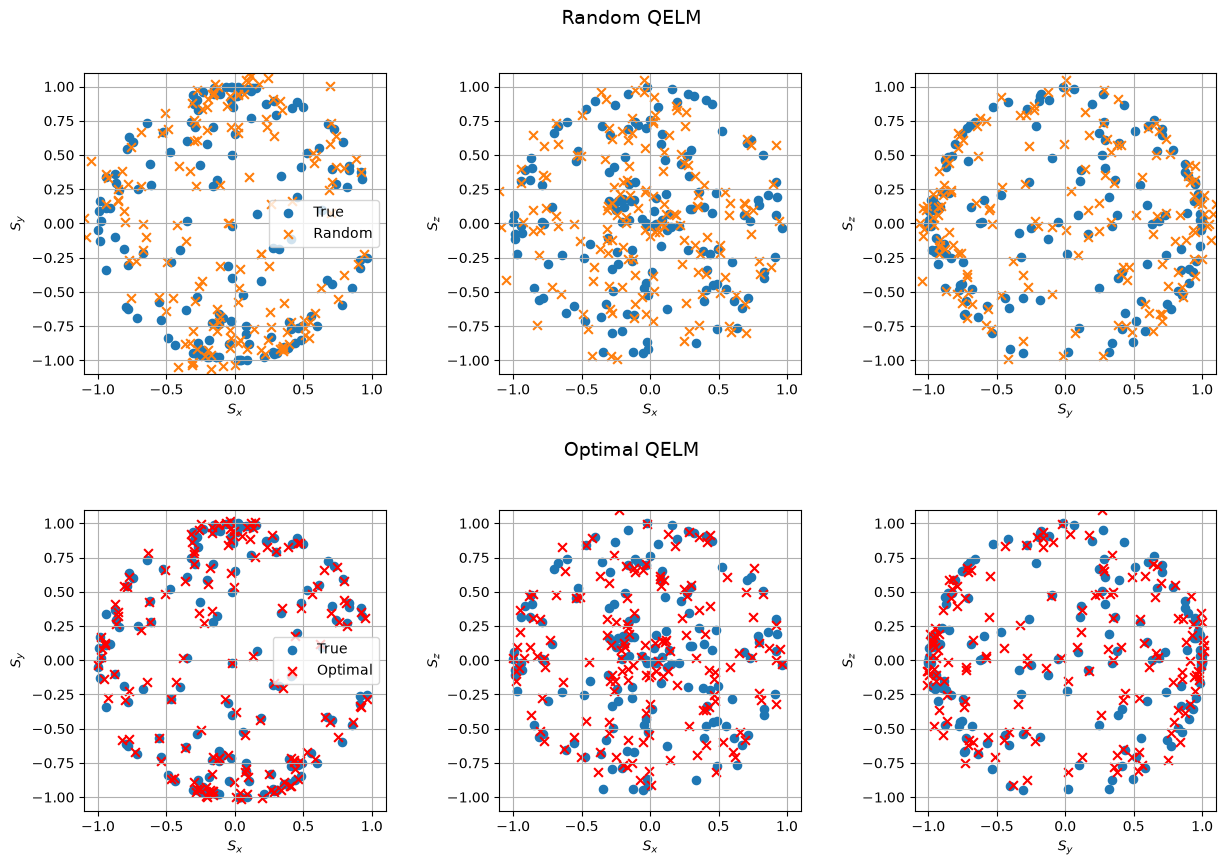

In [36]:
# --------------------------------------------------
# FINAL 10,000-PHOTON RECONSTRUCTION
# --------------------------------------------------

W_random_final = train_qelm(
    X_random_fixed[:n_train_total],
    Y_train
)

Y_pred_random_final = predict_qelm(
    X_random_fixed[n_train_total:],

    W_random_final
)


W_opt_final = train_qelm(
    X_opt_fixed[:n_train_total],
    Y_train
)

Y_pred_opt_final = predict_qelm(
    X_opt_fixed[n_train_total:],
    W_opt_final
)

true_bloch = Y_test

# --------------------------------------------------
# BLOCH CROSS-SECTIONS
# --------------------------------------------------

fig, ax = plt.subplots(2, 3, figsize=(15, 9))

planes = [
    (0, 1, r"$S_x$", r"$S_y$"),
    (0, 2, r"$S_x$", r"$S_z$"),
    (1, 2, r"$S_y$", r"$S_z$")
]

# ==================================================
# RANDOM
# ==================================================

for k, (i, j, xlabel, ylabel) in enumerate(planes):

    ax[0, k].scatter(
        true_bloch[:, i],
        true_bloch[:, j],
        label="True",
        s=35
    )

    ax[0, k].scatter(
        Y_pred_random_final[:, i],
        Y_pred_random_final[:, j],
        marker='x',
        s=40,
        label="Random"
    )

    ax[0, k].set_xlabel(xlabel)
    ax[0, k].set_ylabel(ylabel)
    ax[0, k].set_xlim(-1.1, 1.1)
    ax[0, k].set_ylim(-1.1, 1.1)
    ax[0, k].set_aspect('equal')
    ax[0, k].grid(True)


# ==================================================
# OPTIMAL
# ==================================================

for k, (i, j, xlabel, ylabel) in enumerate(planes):

    ax[1, k].scatter(
        true_bloch[:, i],
        true_bloch[:, j],
        label="True",
        s=35
    )

    ax[1, k].scatter(
        Y_pred_opt_final[:, i],
        Y_pred_opt_final[:, j],
        marker='x',
        s=40,
        color='red',
        label="Optimal"
    )

    ax[1, k].set_xlabel(xlabel)
    ax[1, k].set_ylabel(ylabel)
    ax[1, k].set_xlim(-1.1, 1.1)
    ax[1, k].set_ylim(-1.1, 1.1)
    ax[1, k].set_aspect('equal')
    ax[1, k].grid(True)


# ==================================================
# ROW TITLES
# ==================================================

fig.text(
    0.5, 0.96,
    "Random QELM",
    ha='center',
    va='center',
    fontsize=14
)

fig.text(
    0.5, 0.48,
    "Optimal QELM",
    ha='center',
    va='center',
    fontsize=14
)

ax[0, 0].legend()
ax[1, 0].legend()

plt.subplots_adjust(
    top=0.90,
    bottom=0.08,
    hspace=0.45,
    wspace=0.25
)

plt.show()